In [155]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import sys, os
import pandas as pd
import seaborn as sns
from dython.nominal import associations

In [156]:

sys.path.append(os.path.abspath(".."))

from src.data_loader import load_heart_disease

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

df = load_heart_disease()

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nRows per source:")
print(df["source"].value_counts().to_string())

Shape: 920 rows × 15 columns

Rows per source:
source
cleveland        303
hungarian        294
long_beach_va    200
switzerland      123


In [157]:
# Encode source as ordered categorical (1=cleveland, 2=hungarian, 3=long_beach_va, 4=switzerland)
source_order = ["cleveland", "hungarian", "long_beach_va", "switzerland"]
df["source"] = pd.Categorical(df["source"], categories=source_order, ordered=False)
df["source_code"] = df["source"].cat.codes + 1  # codes are 0-based, shift to 1-based

print(df[["source", "source_code"]].drop_duplicates().sort_values("source_code").to_string(index=False))

       source  source_code
    cleveland            1
    hungarian            2
long_beach_va            3
  switzerland            4


## Variable Descriptions

The dataset contains the 14 standard UCI Heart Disease features plus a `source` column indicating the originating cohort. Categorical variables are already numerically encoded.

| Variable      | Description                                              | Type                               | Units / Value Meaning                                                             |
| ------------- | -------------------------------------------------------- | ---------------------------------- | --------------------------------------------------------------------------------- |
| `age`         | Age of patient                                           | Numeric – Continuous               | Years                                                                             |
| `trestbps`    | Resting blood pressure (on admission)                    | Numeric – Continuous               | mm Hg                                                                             |
| `chol`        | Serum cholesterol                                        | Numeric – Continuous               | mg/dl                                                                             |
| `thalach`     | Maximum heart rate achieved during stress test           | Numeric – Continuous               | Beats per minute (bpm)                                                            |
| `oldpeak`     | ST depression induced by exercise relative to rest       | Numeric – Continuous               | mm                                                                                |
| `ca`          | Number of major vessels colored by fluoroscopy           | Numeric – Discrete                 | Count: 0–3 vessels                                                               |
| `sex`         | Biological sex                                           | Categorical – Binary (Nominal)     | 1 = male; 0 = female                                                             |
| `fbs`         | Fasting blood sugar > 120 mg/dl                          | Categorical – Binary (Nominal)     | 1 = true; 0 = false                                                              |
| `exang`       | Exercise-induced angina                                  | Categorical – Binary (Nominal)     | 1 = yes; 0 = no                                                                  |
| `cp`          | Chest pain type                                          | Categorical – Multiclass (Nominal) | 1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic  |
| `restecg`     | Resting ECG results                                      | Categorical – Multiclass (Nominal) | 0 = normal; 1 = ST-T wave abnormality; 2 = left ventricular hypertrophy          |
| `thal`        | Thalassemia test result                                  | Categorical – Multiclass (Nominal) | 3 = normal; 6 = fixed defect; 7 = reversible defect                              |
| `slope`       | Slope of peak exercise ST segment                        | Categorical – Ordinal              | 1 = upsloping; 2 = flat; 3 = downsloping                                         |
| `num`         | Diagnosis — heart disease severity **(target)**          | Numeric – Ordinal                  | 0 = no disease; 1–4 = increasing severity (often binarised: 0 vs. 1–4)           |
| `source`      | Originating cohort (string label)                        | Categorical (Nominal)              | cleveland, hungarian, long\_beach\_va, switzerland                                |
| `source_code` | Originating cohort (numeric code)                        | Categorical (Nominal)              | 1 = cleveland; 2 = hungarian; 3 = long\_beach\_va; 4 = switzerland               |

In [158]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source,source_code
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland,1
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland,1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland,1
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0,cleveland,1
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3,cleveland,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0,cleveland,1
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2,cleveland,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1,cleveland,1


In [159]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source_code
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652,2.155435
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693,1.028840
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000,1.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,1.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000,2.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000,3.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,4.000000


# Missing Values Matrix


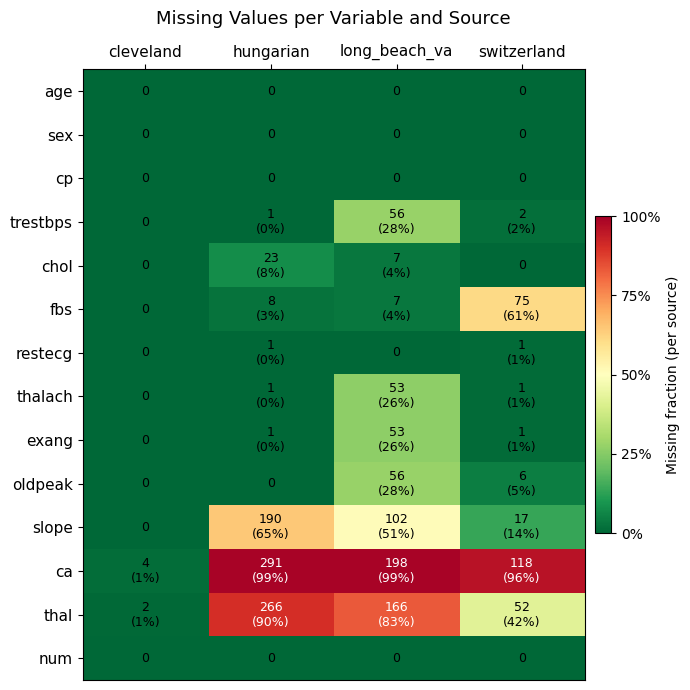

In [160]:

FEATURE_COLS = ["age", "sex", "cp", "trestbps", "chol", "fbs",
                "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
SOURCE_TOTALS = {"cleveland": 303, "hungarian": 294, "long_beach_va": 200, "switzerland": 123}

# Build missing-count matrix (rows=variables, cols=sources)
missing_counts = pd.DataFrame(
    {s: [df.loc[df["source"] == s, col].isna().sum() for col in FEATURE_COLS]
     for s in SOURCES},
    index=FEATURE_COLS,
)

# Build missing-fraction matrix for coloring
missing_pct = missing_counts.copy().astype(float)
for s in SOURCES:
    missing_pct[s] = missing_counts[s] / SOURCE_TOTALS[s]

fig, ax = plt.subplots(figsize=(7, 7))

# Green (0%) → Red (100%) colormap
cmap = plt.cm.RdYlGn_r

im = ax.imshow(missing_pct.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

# Axes labels
ax.set_xticks(range(len(SOURCES)))
ax.set_xticklabels(SOURCES, fontsize=11)
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Annotate each cell with count and percentage
for row_i, col in enumerate(FEATURE_COLS):
    for col_j, s in enumerate(SOURCES):
        count = missing_counts.loc[col, s]
        pct   = missing_pct.loc[col, s]
        label = f"{count}\n({pct:.0%})" if count > 0 else "0"
        text_color = "white" if pct > 0.75 else "black"
        ax.text(col_j, row_i, label,
                ha="center", va="center", fontsize=9, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Missing fraction (per source)", fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])

ax.set_title("Missing Values per Variable and Source", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig("../results/figures/eda_missing_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


# EDA - continuous numeric variables

- age
- trestbps
- chol
- thalach
- oldpeak

In [161]:

os.makedirs("../results", exist_ok=True)

SOURCES = ["cleveland", "hungarian", "long_beach_va", "switzerland"]
SOURCE_COLORS = {
    "cleveland":     "#4C72B0",
    "hungarian":     "#DD8452",
    "long_beach_va": "#55A868",
    "switzerland":   "#C44E52",
}

def plot_missing_per_source(ax, col):
    """Bar chart of missing value counts per source for a given column."""
    missing = [df.loc[df["source"] == s, col].isna().sum() for s in SOURCES]
    bars = ax.bar(SOURCES, missing, color=[SOURCE_COLORS[s] for s in SOURCES])
    ax.set_title(f"{col} — Missing Values per Source")
    ax.set_xlabel("Source")
    ax.set_ylabel("Missing Count")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, missing):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                str(val), ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15)


C:\Users\joshu\AppData\Local\Temp\ipykernel_10764\4246283666.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_source, labels=all_sources, patch_artist=True, notch=False)


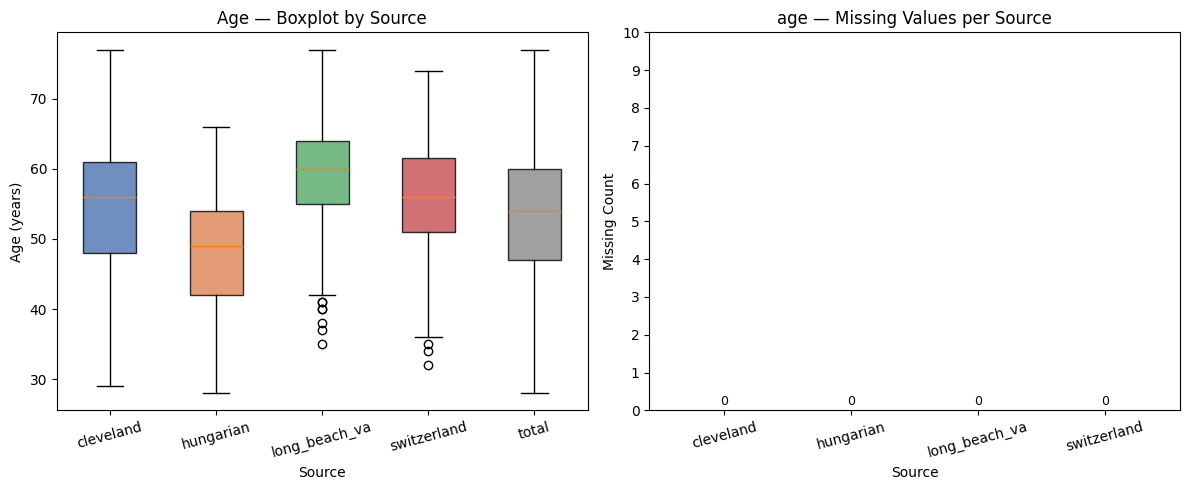

In [162]:
# --- age: boxplot per source + total ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

all_sources = SOURCES + ["total"]
data_by_source = [df.loc[df["source"] == s, "age"].dropna().values for s in SOURCES]
data_by_source.append(df["age"].dropna().values)

bp = axes[0].boxplot(data_by_source, labels=all_sources, patch_artist=True, notch=False)
colors = [SOURCE_COLORS[s] for s in SOURCES] + ["#888888"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
axes[0].set_title("Age — Boxplot by Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Age (years)")
axes[0].tick_params(axis="x", rotation=15)

plot_missing_per_source(axes[1], "age")
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_boxplot_age.png", dpi=150, bbox_inches="tight")
plt.show()


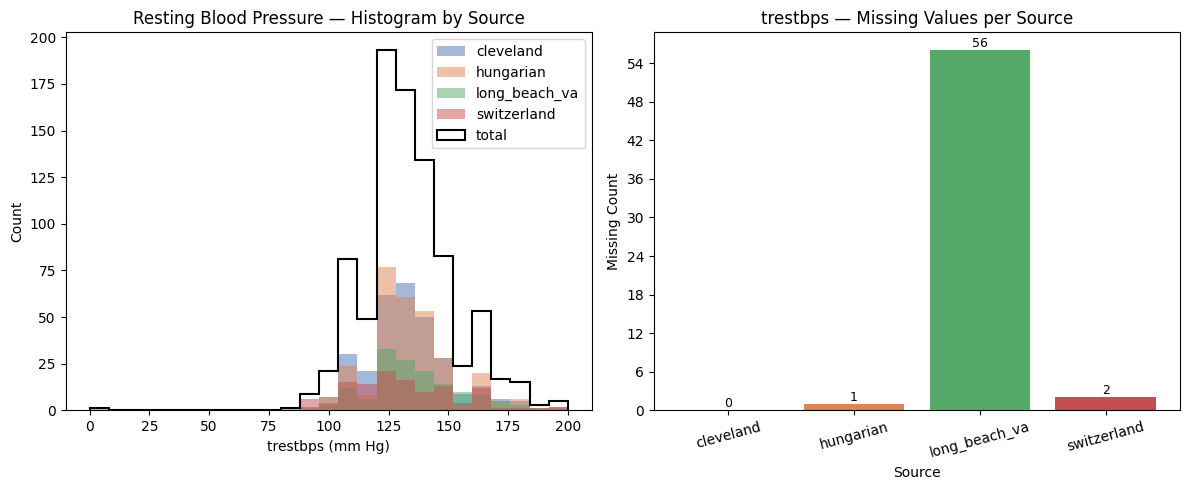

In [163]:
# --- trestbps: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["trestbps"].dropna().min(), df["trestbps"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "trestbps"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["trestbps"].dropna(), bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("Resting Blood Pressure — Histogram by Source")
axes[0].set_xlabel("trestbps (mm Hg)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "trestbps")

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_histogram_trestbps.png", dpi=150, bbox_inches="tight")
plt.show()


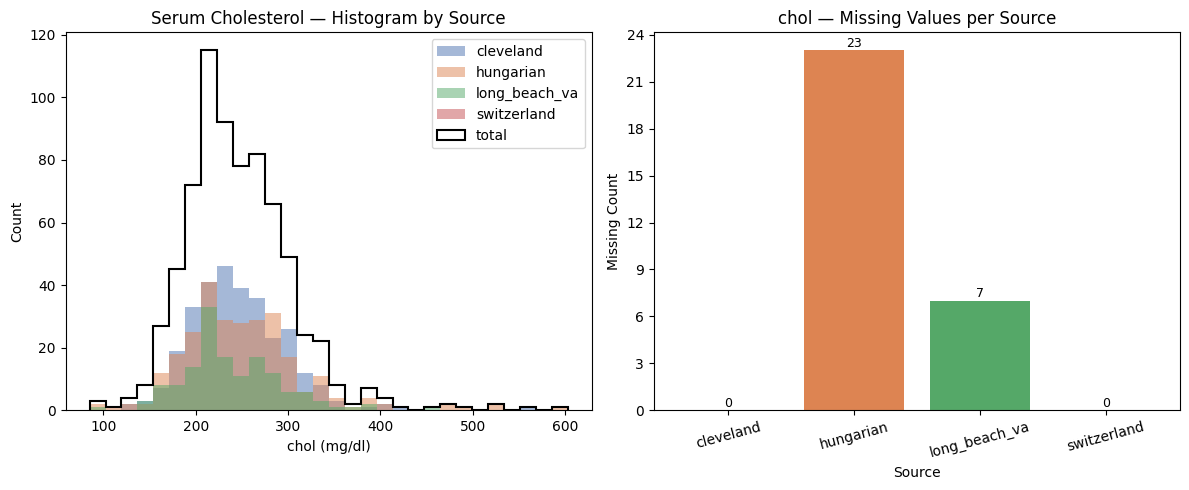

In [164]:
# --- chol: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

chol_valid = df.loc[df["chol"] > 0, "chol"].dropna()
bins = np.linspace(chol_valid.min(), chol_valid.max(), 31)
for s in SOURCES:
    vals = df.loc[(df["source"] == s) & (df["chol"] > 0), "chol"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(chol_valid, bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("Serum Cholesterol — Histogram by Source")
axes[0].set_xlabel("chol (mg/dl)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "chol")

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_histogram_chol.png", dpi=150, bbox_inches="tight")
plt.show()


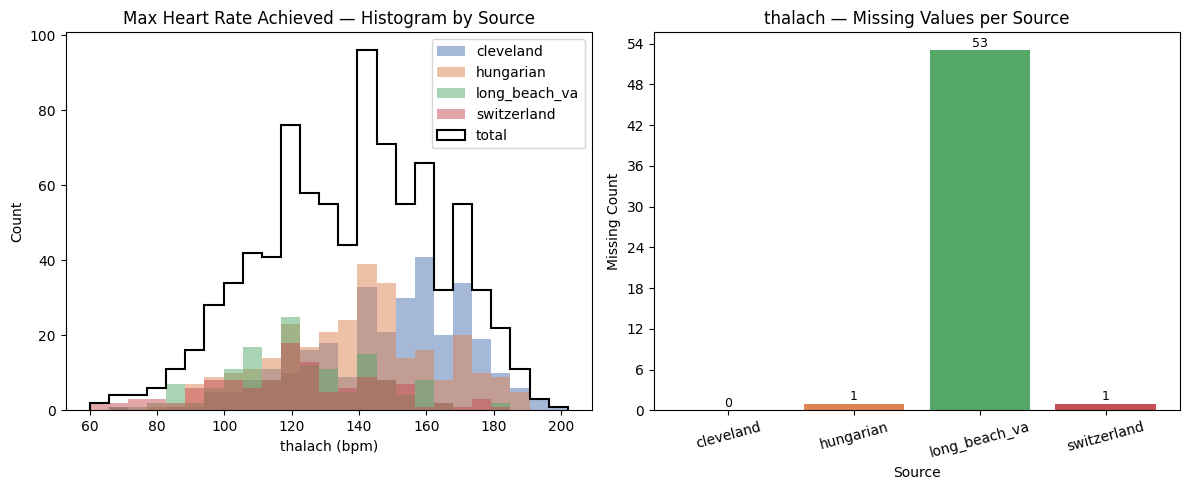

In [165]:
# --- thalach: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["thalach"].dropna().min(), df["thalach"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "thalach"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["thalach"].dropna(), bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("Max Heart Rate Achieved — Histogram by Source")
axes[0].set_xlabel("thalach (bpm)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "thalach")

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_histogram_thalach.png", dpi=150, bbox_inches="tight")
plt.show()


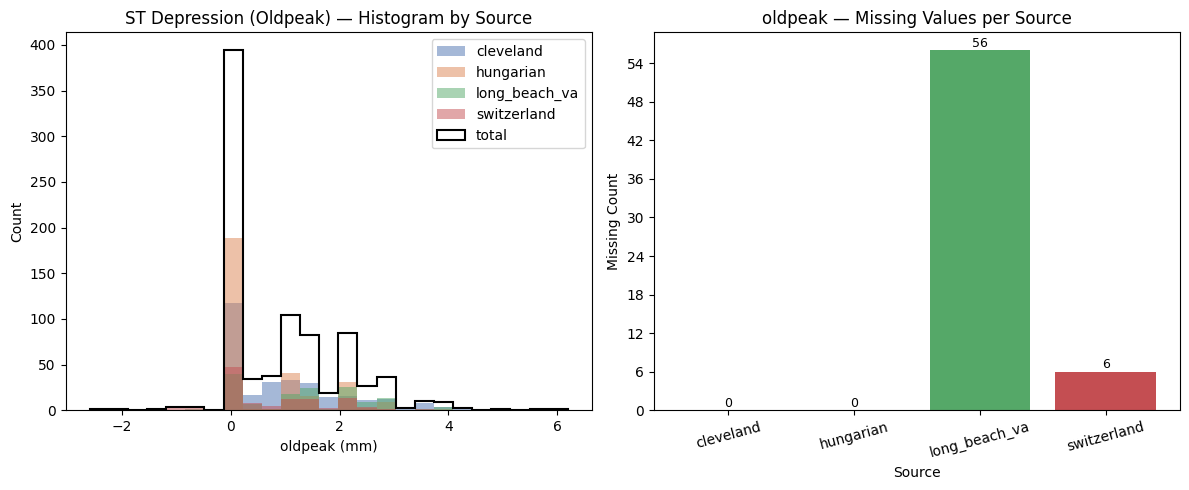

In [166]:
# --- oldpeak: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["oldpeak"].dropna().min(), df["oldpeak"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "oldpeak"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["oldpeak"].dropna(), bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("ST Depression (Oldpeak) — Histogram by Source")
axes[0].set_xlabel("oldpeak (mm)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "oldpeak")

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_histogram_oldpeak.png", dpi=150, bbox_inches="tight")
plt.show()


## Scatter Plots — Continuous Variable Pairs

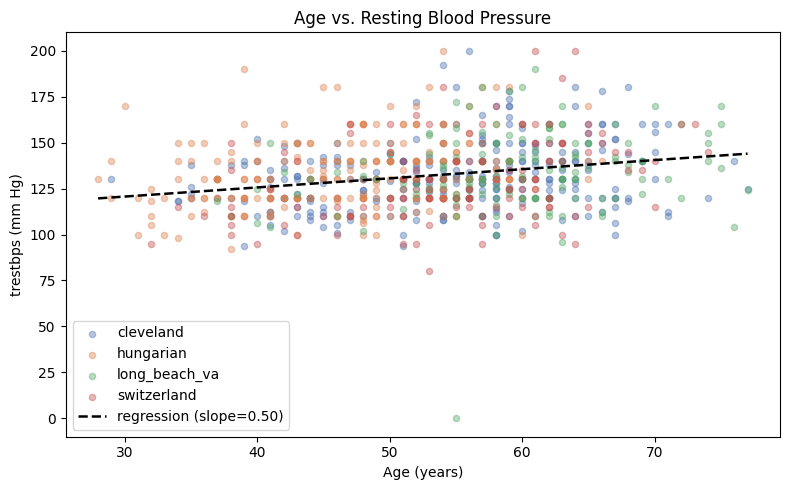

In [167]:
# --- Scatter: age vs. trestbps ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[df["source"] == s, ["age", "trestbps"]].dropna()
    ax.scatter(sub["age"], sub["trestbps"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df[["age", "trestbps"]].dropna()
m, b = np.polyfit(xy["age"], xy["trestbps"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Resting Blood Pressure")
ax.set_xlabel("Age (years)")
ax.set_ylabel("trestbps (mm Hg)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_scatter_age_trestbps.png", dpi=150, bbox_inches="tight")
plt.show()


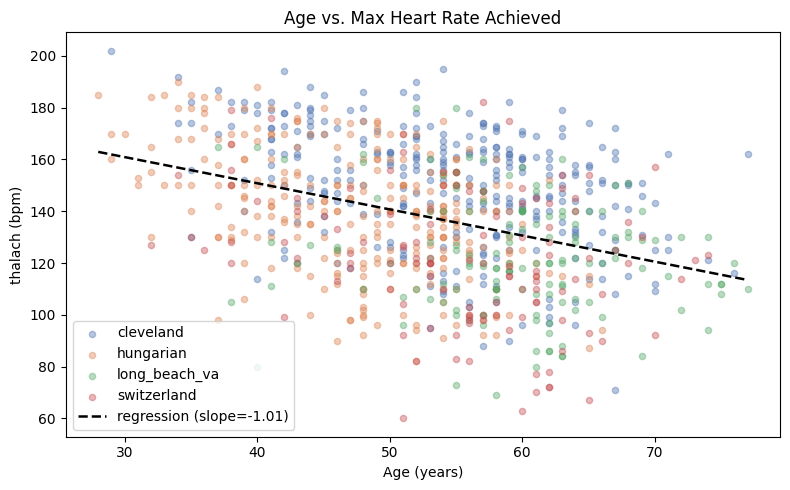

In [168]:
# --- Scatter: age vs. thalach ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[df["source"] == s, ["age", "thalach"]].dropna()
    ax.scatter(sub["age"], sub["thalach"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df[["age", "thalach"]].dropna()
m, b = np.polyfit(xy["age"], xy["thalach"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Max Heart Rate Achieved")
ax.set_xlabel("Age (years)")
ax.set_ylabel("thalach (bpm)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_scatter_age_thalach.png", dpi=150, bbox_inches="tight")
plt.show()


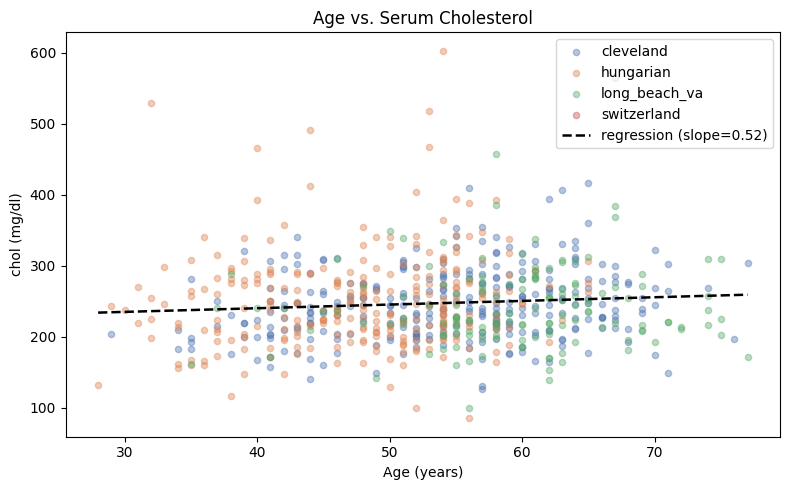

In [169]:
# --- Scatter: age vs. chol ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[(df["source"] == s) & (df["chol"] > 0), ["age", "chol"]].dropna()
    ax.scatter(sub["age"], sub["chol"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df.loc[df["chol"] > 0, ["age", "chol"]].dropna()
m, b = np.polyfit(xy["age"], xy["chol"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Serum Cholesterol")
ax.set_xlabel("Age (years)")
ax.set_ylabel("chol (mg/dl)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_scatter_age_chol.png", dpi=150, bbox_inches="tight")
plt.show()


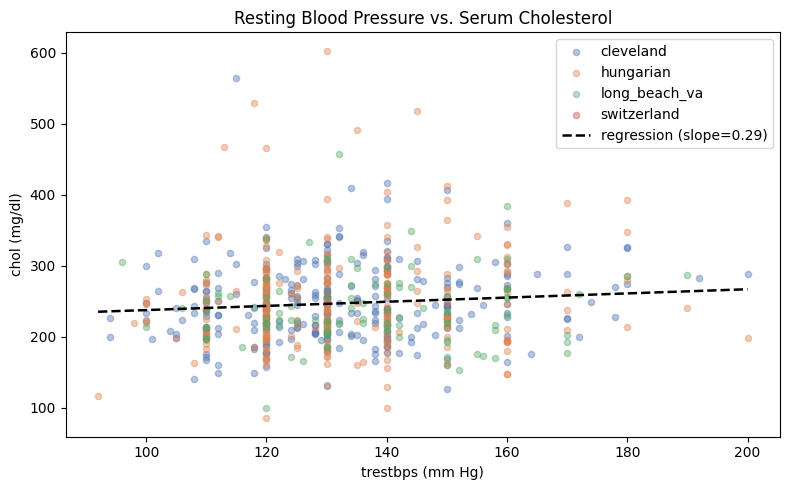

In [170]:
# --- Scatter: trestbps vs. chol ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[(df["source"] == s) & (df["chol"] > 0), ["trestbps", "chol"]].dropna()
    ax.scatter(sub["trestbps"], sub["chol"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df.loc[df["chol"] > 0, ["trestbps", "chol"]].dropna()
m, b = np.polyfit(xy["trestbps"], xy["chol"], 1)
x_line = np.array([xy["trestbps"].min(), xy["trestbps"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Resting Blood Pressure vs. Serum Cholesterol")
ax.set_xlabel("trestbps (mm Hg)")
ax.set_ylabel("chol (mg/dl)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_numeric_scatter_trestbps_chol.png", dpi=150, bbox_inches="tight")
plt.show()


# EDA - categorical variables

## Binary
- sex
- fbs
- exang

## Multiclass:
- cp
- restecg
- thal
- slope

In [171]:
# --- Categorical EDA: shared helpers and color constants ---

NUM_LEVELS  = [0, 1, 2, 3, 4]
BINARY_COLORS = ["#5B9BD5", "#ED7D31"]   # blue = 0, orange = 1
MULTI_COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]


def plot_cat_by_group(ax, df, col, groupby, group_order, cat_labels, cat_colors, title, xlabel):
    """Grouped bar chart: groups on x-axis, one bar per category value of col."""
    sub = df[[groupby, col]].dropna()
    cat_vals = sorted(sub[col].unique())
    n_cats = len(cat_vals)
    width = 0.7 / n_cats
    x = np.arange(len(group_order))

    for i, val in enumerate(cat_vals):
        counts = [sub.loc[sub[groupby] == g, col].eq(val).sum() for g in group_order]
        offset = (i - (n_cats - 1) / 2) * width
        label = cat_labels.get(int(val), str(int(val)))
        ax.bar(x + offset, counts, width=width, label=label,
               color=cat_colors[i % len(cat_colors)], alpha=0.85,
               edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([str(g) for g in group_order], rotation=15, ha="right")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)


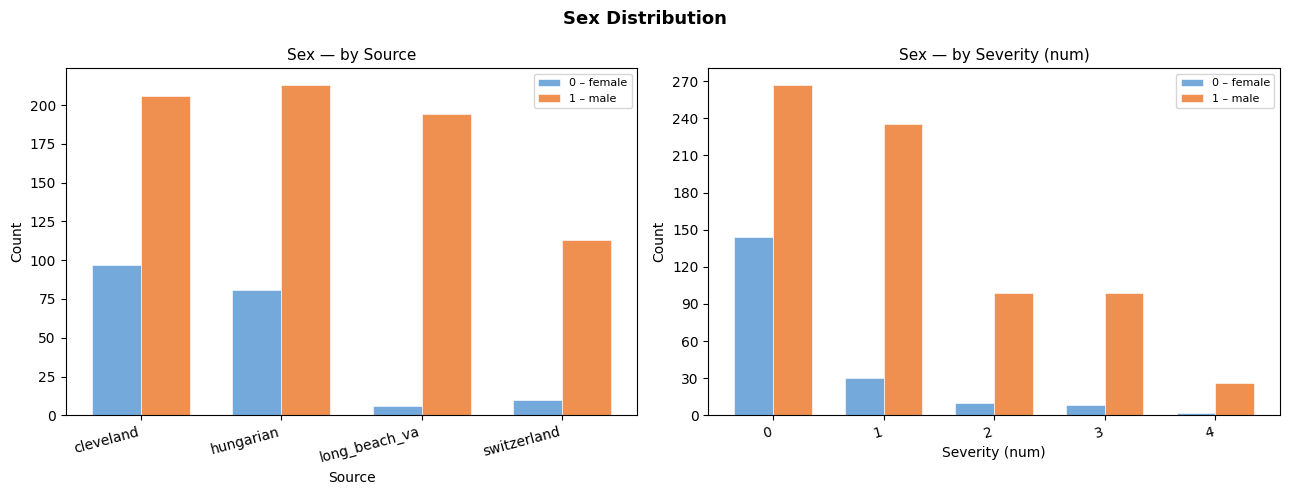

In [172]:
# --- sex: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – female", 1: "1 – male"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cat_by_group(axes[0], df, "sex", "source", SOURCES, cat_labels, BINARY_COLORS,
                  "Sex — by Source", "Source")
plot_cat_by_group(axes[1], df, "sex", "num", NUM_LEVELS, cat_labels, BINARY_COLORS,
                  "Sex — by Severity (num)", "Severity (num)")
fig.suptitle("Sex Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/eda_categorical_bar_sex.png", dpi=150, bbox_inches="tight")
plt.show()


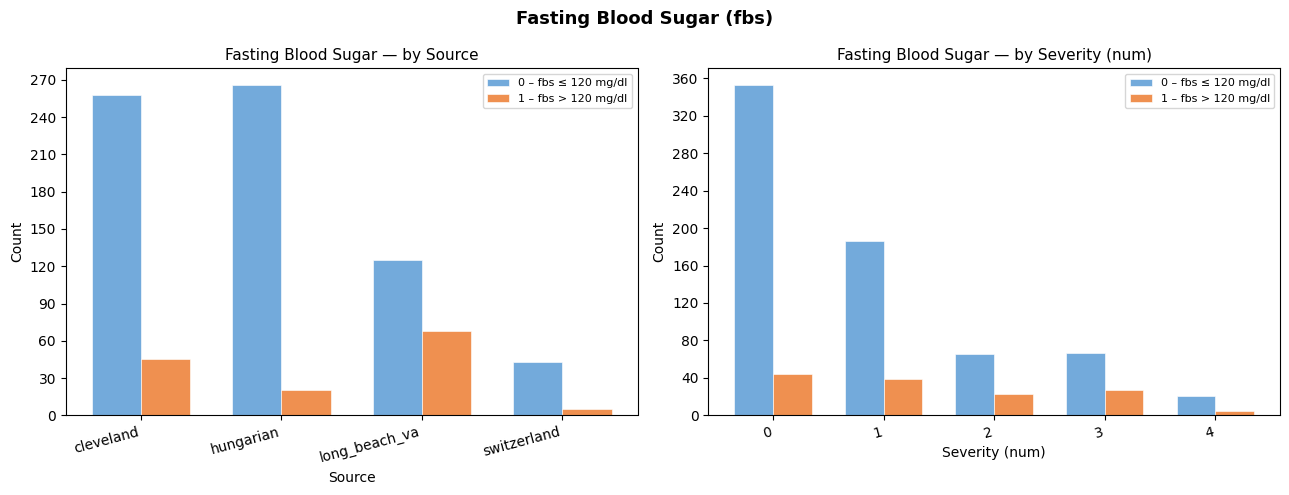

In [173]:
# --- fbs: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – fbs ≤ 120 mg/dl", 1: "1 – fbs > 120 mg/dl"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cat_by_group(axes[0], df, "fbs", "source", SOURCES, cat_labels, BINARY_COLORS,
                  "Fasting Blood Sugar — by Source", "Source")
plot_cat_by_group(axes[1], df, "fbs", "num", NUM_LEVELS, cat_labels, BINARY_COLORS,
                  "Fasting Blood Sugar — by Severity (num)", "Severity (num)")
fig.suptitle("Fasting Blood Sugar (fbs)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/eda_categorical_bar_fbs.png", dpi=150, bbox_inches="tight")
plt.show()


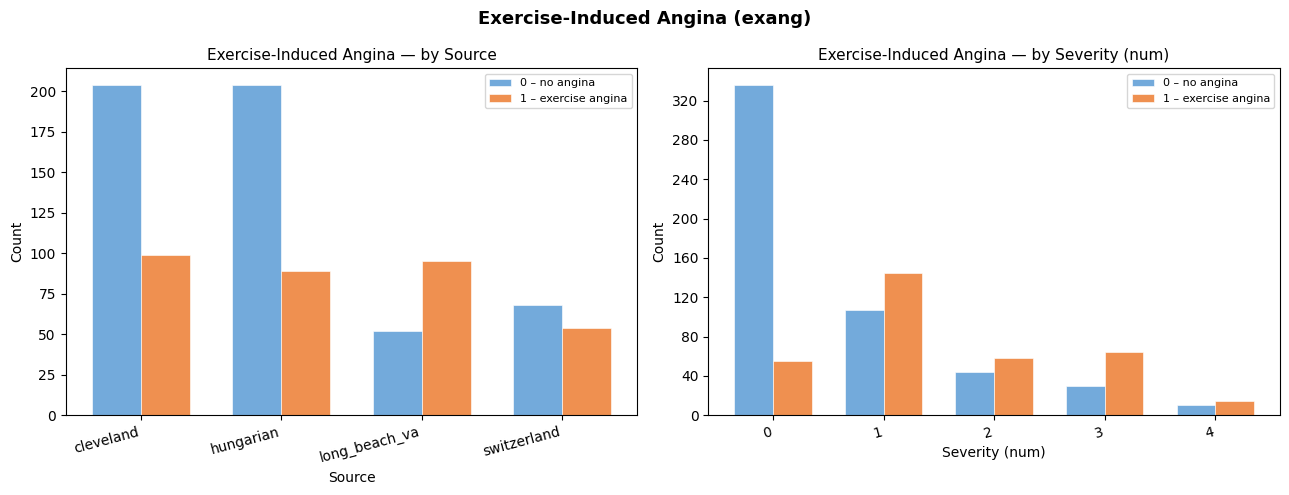

In [174]:
# --- exang: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – no angina", 1: "1 – exercise angina"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cat_by_group(axes[0], df, "exang", "source", SOURCES, cat_labels, BINARY_COLORS,
                  "Exercise-Induced Angina — by Source", "Source")
plot_cat_by_group(axes[1], df, "exang", "num", NUM_LEVELS, cat_labels, BINARY_COLORS,
                  "Exercise-Induced Angina — by Severity (num)", "Severity (num)")
fig.suptitle("Exercise-Induced Angina (exang)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/eda_categorical_bar_exang.png", dpi=150, bbox_inches="tight")
plt.show()


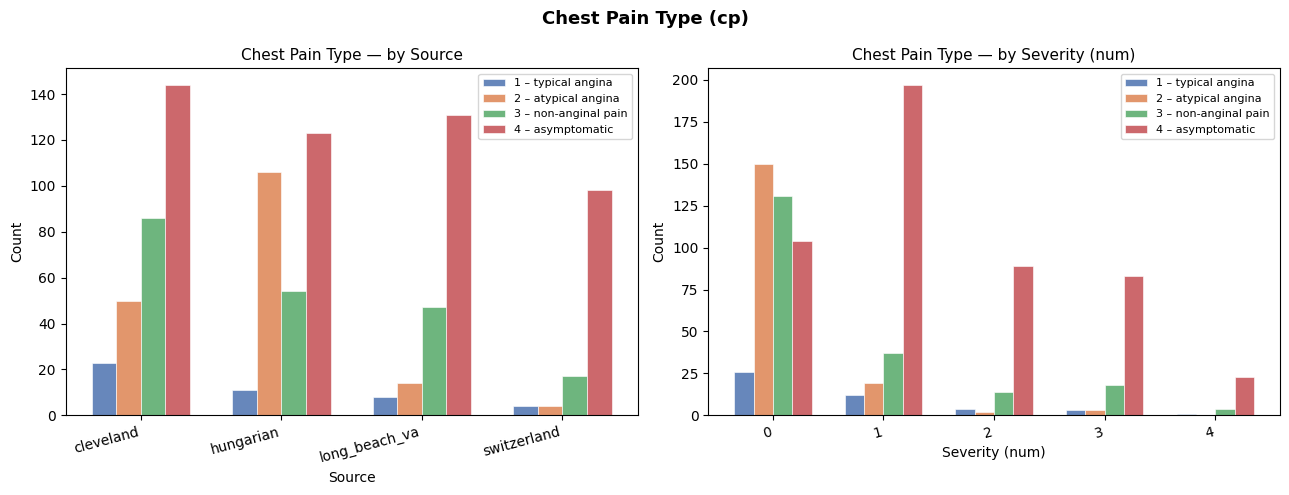

In [175]:
# --- cp: distribution by source (left) and by severity (right) ---
cat_labels = {1: "1 – typical angina", 2: "2 – atypical angina",
              3: "3 – non-anginal pain", 4: "4 – asymptomatic"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cat_by_group(axes[0], df, "cp", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "Chest Pain Type — by Source", "Source")
plot_cat_by_group(axes[1], df, "cp", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "Chest Pain Type — by Severity (num)", "Severity (num)")
fig.suptitle("Chest Pain Type (cp)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/eda_categorical_bar_cp.png", dpi=150, bbox_inches="tight")
plt.show()


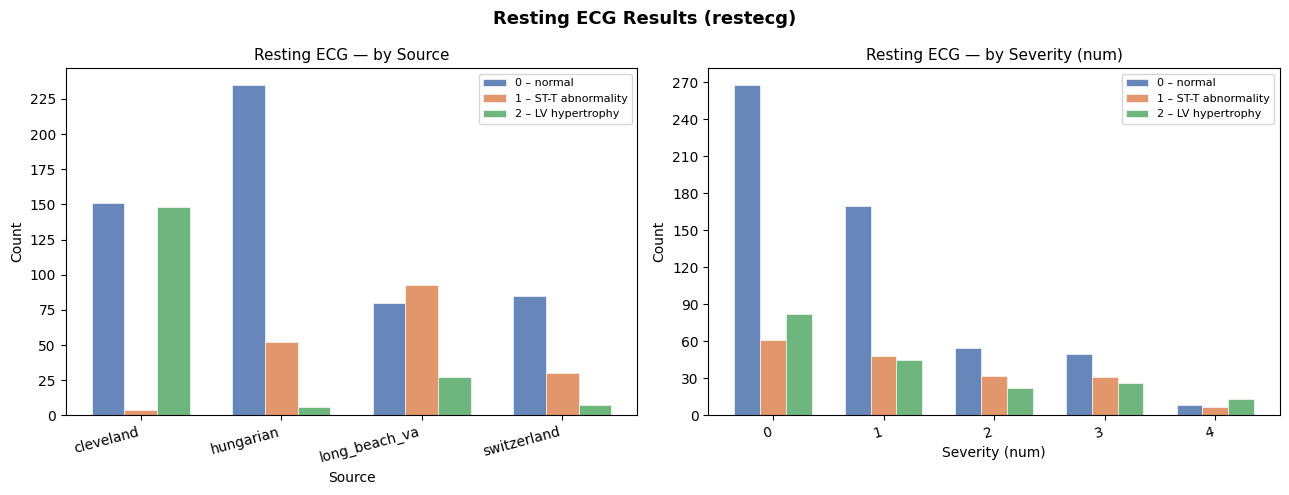

In [176]:
# --- restecg: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – normal", 1: "1 – ST-T abnormality", 2: "2 – LV hypertrophy"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cat_by_group(axes[0], df, "restecg", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "Resting ECG — by Source", "Source")
plot_cat_by_group(axes[1], df, "restecg", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "Resting ECG — by Severity (num)", "Severity (num)")
fig.suptitle("Resting ECG Results (restecg)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/eda_categorical_bar_restecg.png", dpi=150, bbox_inches="tight")
plt.show()


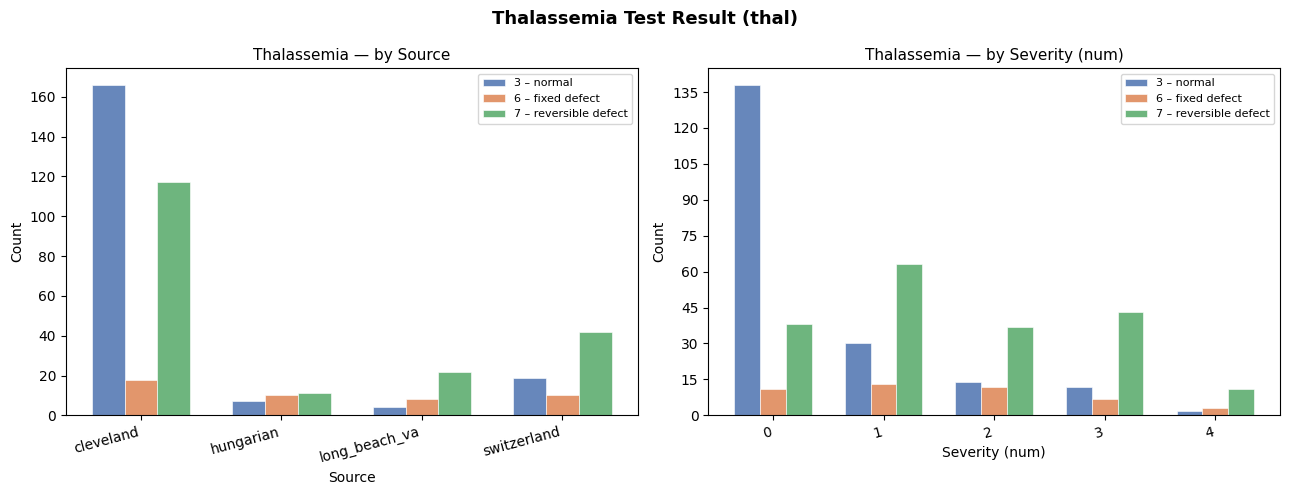

In [177]:
# --- thal: distribution by source (left) and by severity (right) ---
cat_labels = {3: "3 – normal", 6: "6 – fixed defect", 7: "7 – reversible defect"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cat_by_group(axes[0], df, "thal", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "Thalassemia — by Source", "Source")
plot_cat_by_group(axes[1], df, "thal", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "Thalassemia — by Severity (num)", "Severity (num)")
fig.suptitle("Thalassemia Test Result (thal)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/eda_categorical_bar_thal.png", dpi=150, bbox_inches="tight")
plt.show()


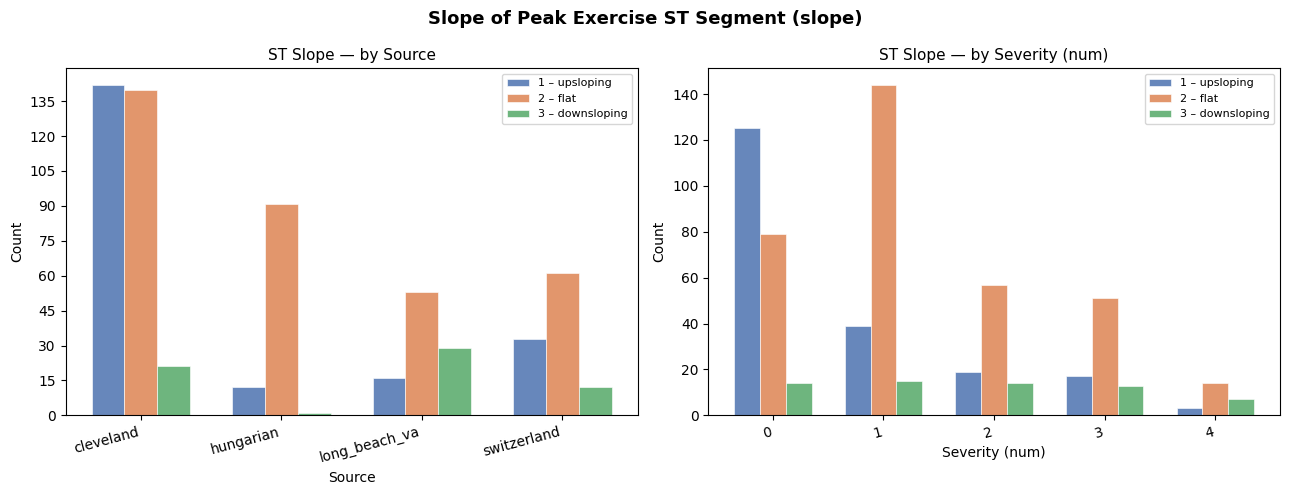

In [178]:
# --- slope: distribution by source (left) and by severity (right) ---
cat_labels = {1: "1 – upsloping", 2: "2 – flat", 3: "3 – downsloping"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cat_by_group(axes[0], df, "slope", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "ST Slope — by Source", "Source")
plot_cat_by_group(axes[1], df, "slope", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "ST Slope — by Severity (num)", "Severity (num)")
fig.suptitle("Slope of Peak Exercise ST Segment (slope)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/eda_categorical_bar_slope.png", dpi=150, bbox_inches="tight")
plt.show()


# Correlation Matrix

## Correlation Strategy

Not all variables can be compared with the same measure. The appropriate statistic depends on the **measurement level** of the variables involved.

| Method | When to use | Assumption | Range |
|---|---|---|---|
| **Pearson r** | Two continuous variables | Linear relationship, (approx.) normal distribution | −1 to +1 |
| **Spearman ρ** | Continuous *or* ordinal variables | Monotonic relationship; no normality required | −1 to +1 |
| **Cramér's V** | Two nominal (categorical) variables | None — based on χ² test of independence | 0 to +1 |

### Why not Pearson / Spearman for nominal variables?

Nominal variables have **no meaningful numeric order**. For example, chest pain type `cp` is coded 1–4:

- 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic

Using Pearson or Spearman would imply that *asymptomatic (4) is four times more severe than typical angina (1)*, which is meaningless — the codes are just labels. Cramér's V instead tests whether the **distribution of categories differs** between groups, without assuming any ordering.

---

## Matrix A — Continuous & Ordinal Variables (Spearman ρ)

Variables: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`, `slope`, `num`

Spearman is chosen because `ca` (count, 0–3), `slope` (ordinal), and `num` (ordinal target) are not purely continuous, and the continuous variables are not guaranteed to be normally distributed.


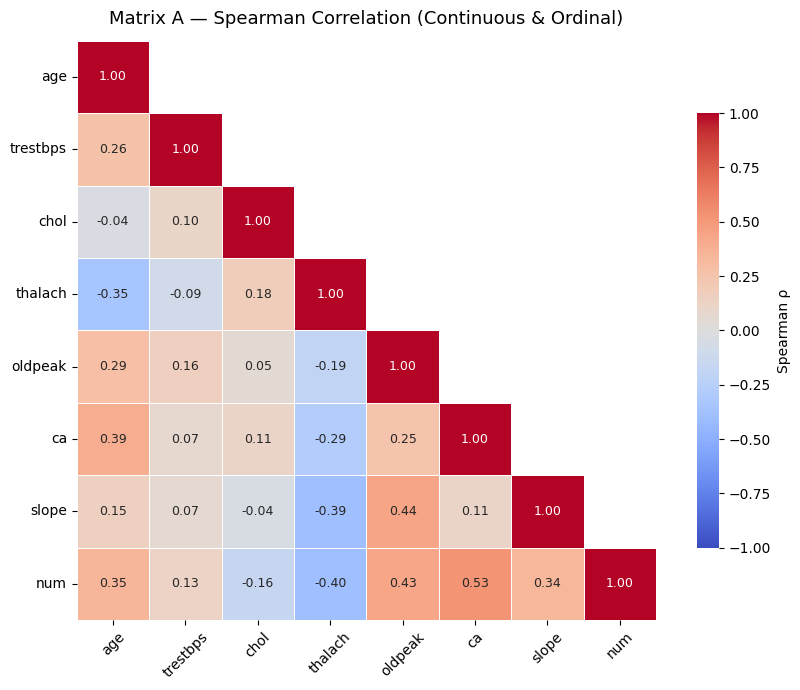

In [179]:
ORDINAL_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "slope", "num"]

corr_a = df[ORDINAL_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.zeros_like(corr_a, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle (keep lower + diagonal)

sns.heatmap(
    corr_a,
    ax=ax,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Spearman ρ"},
)

ax.set_title("Matrix A — Spearman Correlation (Continuous & Ordinal)", fontsize=13, pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig("../results/figures/eda_correlation_matrix_a_spearman.png", dpi=150, bbox_inches="tight")
plt.show()


## Matrix B — Categorical Association Matrix (Cramér's V)

Variables: `sex`, `fbs`, `exang`, `cp`, `restecg`, `thal`, `source_code`, `target` (num binarized: 0 = no disease, 1 = disease)

All variables here are **nominal categorical** — none have a meaningful numeric order. Cramér's V is derived from the χ² statistic and measures the strength of association between two categorical variables. Unlike Pearson/Spearman, it is always **0–1** (no direction), where 0 = no association and 1 = perfect association.

[dython](http://shakedzy.xyz/dython/) `associations()` automatically applies Cramér's V for all nominal-nominal pairs.


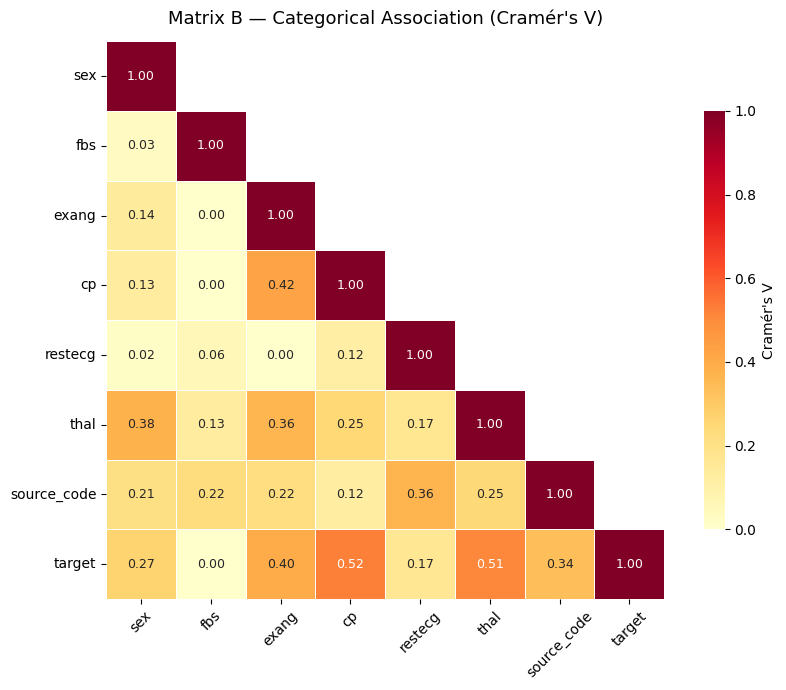

In [180]:
CAT_COLS = ["sex", "fbs", "exang", "cp", "restecg", "thal", "source_code"]

df_cat = df[CAT_COLS].copy()
df_cat["target"] = (df["num"] > 0).astype(int)  # binarize: 0 = no disease, 1 = disease

# Cast all to string-category so dython treats them as nominal
for col in df_cat.columns:
    df_cat[col] = df_cat[col].astype("category")

result = associations(
    df_cat,
    nominal_columns="all",
    plot=False,
    nan_strategy="drop_samples",
)
corr_b = result["corr"]

fig, ax = plt.subplots(figsize=(9, 7))

mask_b = np.zeros_like(corr_b, dtype=bool)
mask_b[np.triu_indices_from(mask_b, k=1)] = True

sns.heatmap(
    corr_b,
    ax=ax,
    mask=mask_b,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Cramér's V"},
)

ax.set_title("Matrix B — Categorical Association (Cramér's V)", fontsize=13, pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig("../results/figures/eda_correlation_matrix_b_cramers_v.png", dpi=150, bbox_inches="tight")
plt.show()


## Matrix C — Full Association Matrix (all variables)

Matrix A and B only capture within-type associations. The question *"Does chest pain type (cp) influence maximum heart rate (thalach)?"* — one nominal, one numeric — falls into neither.

dython's `associations()` fills this gap by applying the right measure for each pair automatically:

| Pair type | Measure applied |
|---|---|
| Numeric × Numeric | Pearson r |
| Categorical × Categorical | Cramér's V |
| Numeric × Categorical | Correlation Ratio η (how much of the numeric variable's variance is explained by the categorical grouping) |

The resulting matrix is **symmetric** and covers all cross-type relationships in one view. Nominal columns are declared explicitly so dython does not mis-treat coded integers (e.g. `cp = 3`) as continuous.


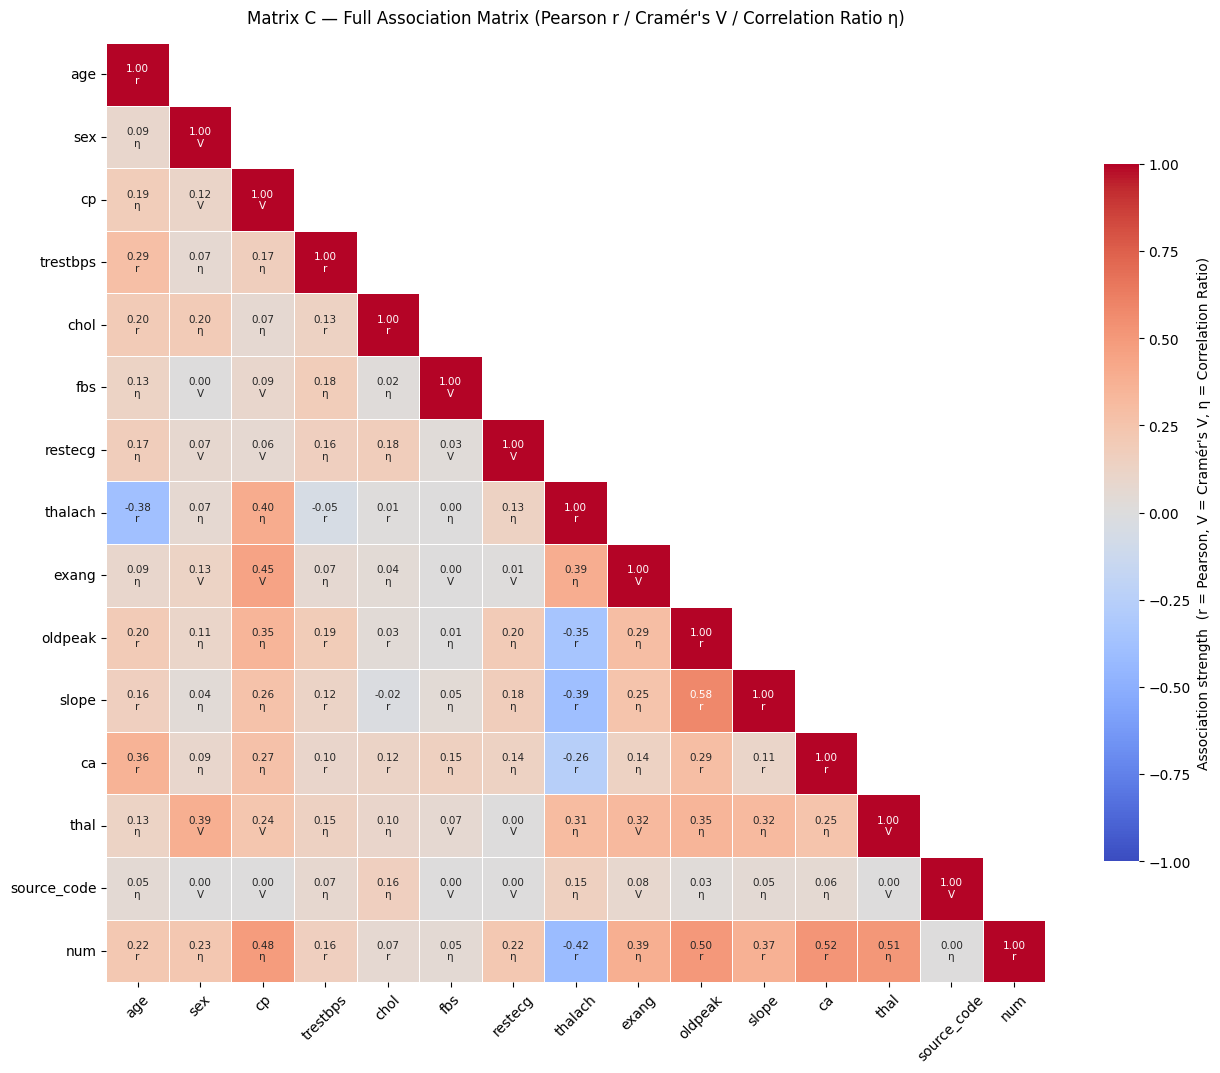

In [181]:
ALL_COLS = ["age", "sex", "cp", "trestbps", "chol", "fbs",
            "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal",
            "source_code", "num"]

# Declare which columns are nominal so dython doesn't treat their codes as numeric
NOMINAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "thal", "source_code"]

df_all = df[ALL_COLS].copy()

result_c = associations(
    df_all,
    nominal_columns=NOMINAL_COLS,
    plot=False,
    nan_strategy="drop_samples",
)
corr_c = result_c["corr"]

# Build annotation matrix that shows the measure type per cell
NUMERIC_COLS = [c for c in ALL_COLS if c not in NOMINAL_COLS]

def cell_label(r, c):
    """Return formatted value + measure symbol for each cell."""
    v = corr_c.loc[r, c]
    r_num = r in NUMERIC_COLS
    c_num = c in NUMERIC_COLS
    if r_num and c_num:
        sym = "r"
    elif not r_num and not c_num:
        sym = "V"
    else:
        sym = "η"
    return f"{v:.2f}\n{sym}"

annot = pd.DataFrame(
    [[cell_label(r, c) for c in corr_c.columns] for r in corr_c.index],
    index=corr_c.index,
    columns=corr_c.columns,
)

fig, ax = plt.subplots(figsize=(13, 11))

mask_c = np.zeros_like(corr_c, dtype=bool)
mask_c[np.triu_indices_from(mask_c, k=1)] = True

sns.heatmap(
    corr_c,
    ax=ax,
    mask=mask_c,
    annot=annot,
    fmt="",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7.5},
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Association strength  (r = Pearson, V = Cramér's V, η = Correlation Ratio)"},
)

ax.set_title("Matrix C — Full Association Matrix (Pearson r / Cramér's V / Correlation Ratio η)",
             fontsize=12, pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig("../results/figures/eda_correlation_matrix_c_full.png", dpi=150, bbox_inches="tight")
plt.show()
